# Cox Proportional Hazards Analysis with Time-Dependent Covariates

## Analysis of Time to Promotion from Captain to Major in US Army Officers

This notebook analyzes factors affecting promotion timing from Captain to Major using Cox proportional hazards regression with time-dependent covariates.

### Study Design:
- **Event**: Promotion from Captain (CPT) to Major (MAJ)
- **Time**: From first CPT snapshot to promotion or censoring
- **Censoring**: End of study (9/30/2007) or early departure
- **Covariates**: Sex (fixed), Marriage status (time-dependent), Job code and changes (time-dependent), Age (time-dependent)


In [1]:
import lifelines
print(lifelines.__version__)
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from lifelines import datasets, CoxPHFitter
from lifelines.utils import to_long_format
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")

print("Libraries imported successfully!")
print("Note: plot_partial_effects_on_outcome is a method of CoxPHFitter, not a separate import")


0.30.0
Libraries imported successfully!
Note: plot_partial_effects_on_outcome is a method of CoxPHFitter, not a separate import


# Load the data

In [2]:
# Load the data
df = pd.read_csv('cox_model/cox_data.csv')

# Display basic information about the dataset
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst few rows:")
df.head(10)


Dataset shape: (312, 23)

Columns: ['snpsht_dt', 'pid_pde', 'rank_pde', 'sex', 'age', 'job_code', 'married', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22']

First few rows:


,snpsht_dt,pid_pde,rank_pde,sex,age,job_code,married,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22
0,3/31/2001,PDE01,CPT,1.0,27.0,11A,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,6/30/2001,PDE01,CPT,1.0,28.0,11A,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,9/30/2001,PDE01,CPT,1.0,28.0,11A,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,12/31/2001,PDE01,CPT,1.0,28.0,11A,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3/31/2002,PDE01,CPT,1.0,28.0,11A,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,6/30/2002,PDE01,CPT,1.0,29.0,11A,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,9/30/2002,PDE01,CPT,1.0,29.0,11A,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,12/31/2002,PDE01,CPT,1.0,29.0,11A,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,3/31/2003,PDE01,CPT,1.0,29.0,11A,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,6/30/2003,PDE01,CPT,1.0,30.0,11A,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Clean the data - remove empty rows and columns

In [3]:
# Clean the data - remove empty rows and columns
df_clean = df.dropna(subset=['pid_pde']).copy()

# Remove extra empty columns
df_clean = df_clean.loc[:, ~df_clean.columns.str.contains('^Unnamed')]
df_clean = df_clean.dropna(how='all', axis=1)

# Convert snapshot date to datetime
df_clean['snpsht_dt'] = pd.to_datetime(df_clean['snpsht_dt'])

# Sort by pid_pde and snapshot date as mentioned
df_clean = df_clean.sort_values(['pid_pde', 'snpsht_dt']).reset_index(drop=True)

print(f"Cleaned dataset shape: {df_clean.shape}")
print(f"\nUnique officers: {df_clean['pid_pde'].nunique()}")
print(f"Date range: {df_clean['snpsht_dt'].min()} to {df_clean['snpsht_dt'].max()}")
print(f"\nRank distribution:")
print(df_clean['rank_pde'].value_counts())
print(f"\nJob code distribution:")
print(df_clean['job_code'].value_counts())


Cleaned dataset shape: (299, 7)

Unique officers: 13
Date range: 2001-03-31 00:00:00 to 2007-09-30 00:00:00

Rank distribution:
rank_pde
CPT    239
MAJ     60
Name: count, dtype: int64

Job code distribution:
job_code
11A    158
12A    107
35A     34
Name: count, dtype: int64


# Consolidated Data Preparation for Cox Analysis (Robust Version)

In [4]:
# CONSOLIDATED DATA PREPARATION FOR COX ANALYSIS (ROBUST VERSION)
# This cell ensures all necessary variables exist for subsequent analysis

print("=== CONSOLIDATED COX DATA PREPARATION ===")

# Ensure we have clean data
if 'df_clean' not in globals():
    print("❌ df_clean not found. Please run data loading and cleaning cells first.")
    raise NameError("df_clean not defined")

# Create Cox regression dataset using the working approach
def create_robust_cox_data(df):
    """Create Cox data with proper error handling"""
    
    cox_data = []
    study_end = pd.to_datetime('2007-09-30')
    
    for pid in df['pid_pde'].unique():
        officer_data = df[df['pid_pde'] == pid].copy().sort_values('snpsht_dt')
        
        # Get basic info
        first_date = officer_data['snpsht_dt'].iloc[0]
        last_date = officer_data['snpsht_dt'].iloc[-1]
        sex = officer_data['sex'].iloc[0]
        
        # Check if promoted to Major
        promoted = 'MAJ' in officer_data['rank_pde'].values
        if promoted:
            promotion_date = officer_data[officer_data['rank_pde'] == 'MAJ']['snpsht_dt'].iloc[0]
            event = 1
            end_date = promotion_date
        else:
            event = 0
            end_date = min(last_date, study_end)
        
        # Filter data properly
        if promoted:
            officer_data_filtered = officer_data[officer_data['snpsht_dt'] < end_date].copy()
        else:
            officer_data_filtered = officer_data[officer_data['snpsht_dt'] <= end_date].copy()
        
        if len(officer_data_filtered) == 0:
            continue
        
        # Calculate time intervals
        for i in range(len(officer_data_filtered)):
            current_row = officer_data_filtered.iloc[i]
            current_date = current_row['snpsht_dt']
            
            start_time = (current_date - first_date).days / 90.25
            
            if i < len(officer_data_filtered) - 1:
                next_date = officer_data_filtered.iloc[i + 1]['snpsht_dt']
                stop_time = (next_date - first_date).days / 90.25
                event_in_interval = 0
            else:
                stop_time = (end_date - first_date).days / 90.25
                event_in_interval = event
            
            if stop_time <= start_time:
                continue
            
            # Job code changes
            job_codes_so_far = officer_data_filtered.iloc[:i+1]['job_code'].unique()
            job_code_changed = len(job_codes_so_far) > 1
            
            cox_data.append({
                'pid_pde': pid,
                'start': start_time,
                'stop': stop_time,
                'event': event_in_interval,
                'sex': sex,
                'married': current_row['married'],
                'age': current_row['age'],
                'job_code': current_row['job_code'],
                'job_code_changed': int(job_code_changed),
                'promoted': promoted
            })
    
    return pd.DataFrame(cox_data)

# Create the main Cox dataset
cox_df = create_robust_cox_data(df_clean)

print(f"Cox dataset created: {cox_df.shape}")
print(f"Events: {cox_df['event'].sum()}")
print(f"Officers: {cox_df['pid_pde'].nunique()}")

# Prepare final modeling dataset
cox_model_df = cox_df[cox_df['stop'] > cox_df['start']].copy()

# Define robust covariate set (only include variables that exist and have variance)
all_potential_covariates = ['sex', 'married', 'age', 'job_code_changed']
final_covariates = []

print(f"\nSelecting covariates:")
for cov in all_potential_covariates:
    if cov in cox_model_df.columns:
        variance = cox_model_df[cov].var()
        unique_vals = cox_model_df[cov].nunique()
        if variance > 1e-10 and unique_vals > 1:
            final_covariates.append(cov)
            print(f"✅ {cov}: variance={variance:.4f}, unique values={unique_vals}")
        else:
            print(f"❌ {cov}: excluded (variance={variance:.4f}, unique values={unique_vals})")
    else:
        print(f"❌ {cov}: not found in data")

print(f"\nFinal dataset ready for modeling:")
print(f"- Shape: {cox_model_df.shape}")
print(f"- Events: {cox_model_df['event'].sum()}")
print(f"- Covariates: {final_covariates}")

# This ensures all subsequent cells have these variables available:
# - cox_df: full Cox dataset
# - cox_model_df: cleaned dataset ready for modeling  
# - final_covariates: list of valid covariates


=== CONSOLIDATED COX DATA PREPARATION ===
Cox dataset created: (233, 10)
Events: 7
Officers: 13

Selecting covariates:
✅ sex: variance=0.1811, unique values=2
✅ married: variance=0.2486, unique values=2
✅ age: variance=9.0333, unique values=16
✅ job_code_changed: variance=0.0859, unique values=2

Final dataset ready for modeling:
- Shape: (233, 10)
- Events: 7
- Covariates: ['sex', 'married', 'age', 'job_code_changed']


# Cox Model Fitting

In [5]:
# CORRECTED Cox Model Fitting (Excludes pid_pde properly)

print("=== CORRECTED COX PROPORTIONAL HAZARDS MODEL ===")

# Initialize the Cox model
cph = CoxPHFitter()

print(f"Dataset shape: {cox_model_df.shape}")
print(f"Events: {cox_model_df['event'].sum()}")
print(f"Available covariates: {final_covariates}")
print(f"All dataset columns: {cox_model_df.columns.tolist()}")

# Create a clean dataset for Cox modeling (exclude non-covariate columns like pid_pde)
cox_columns = ['start', 'stop', 'event'] + final_covariates
cox_clean_df = cox_model_df[cox_columns].copy()

print(f"\nCox modeling dataset shape: {cox_clean_df.shape}")
print(f"Columns for modeling: {cox_clean_df.columns.tolist()}")

# Try to fit the model with available covariates using explicit formula
try:
    formula = ' + '.join(final_covariates)
    print(f"\nFitting Cox model with formula: {formula}")
    print("(This properly excludes pid_pde and other non-covariate columns)")
    
    cph.fit(cox_clean_df, 
            duration_col='stop', 
            event_col='event',
            entry_col='start',
            formula=formula)
    
    print("✅ Cox model fitted successfully!")
    print("\nModel Summary:")
    print(cph.summary)
    
    print(f"\nModel Performance:")
    print(f"Concordance Index: {cph.concordance_index_:.3f}")
    print(f"Log-likelihood: {cph.log_likelihood_:.2f}")
    print(f"AIC: {cph.AIC_:.2f}")
    
except Exception as e:
    print(f"❌ Error fitting full Cox model: {e}")
    
    # Try with a subset of covariates if the full model fails
    print("\nTrying with simplified covariate set...")
    
    # Try with just basic demographics
    simple_covariates = ['sex', 'age']
    available_simple = [cov for cov in simple_covariates if cov in cox_clean_df.columns]
    
    if available_simple:
        try:
            formula = ' + '.join(available_simple)
            print(f"Trying simplified formula: {formula}")
            
            cph.fit(cox_clean_df, 
                    duration_col='stop', 
                    event_col='event',
                    entry_col='start',
                    formula=formula)
            
            print("✅ Simplified Cox model fitted successfully!")
            print(f"Covariates used: {available_simple}")
            print(f"Concordance Index: {cph.concordance_index_:.3f}")
            print("\nModel Summary:")
            print(cph.summary)
            
        except Exception as e2:
            print(f"❌ Even simplified model failed: {e2}")
    else:
        print("No suitable covariates available for simplified model")


=== CORRECTED COX PROPORTIONAL HAZARDS MODEL ===
Dataset shape: (233, 10)
Events: 7
Available covariates: ['sex', 'married', 'age', 'job_code_changed']
All dataset columns: ['pid_pde', 'start', 'stop', 'event', 'sex', 'married', 'age', 'job_code', 'job_code_changed', 'promoted']

Cox modeling dataset shape: (233, 7)
Columns for modeling: ['start', 'stop', 'event', 'sex', 'married', 'age', 'job_code_changed']

Fitting Cox model with formula: sex + married + age + job_code_changed
(This properly excludes pid_pde and other non-covariate columns)
✅ Cox model fitted successfully!

Model Summary:
                       coef     exp(coef)     se(coef)  coef lower 95%  \
covariate                                                                
sex               -1.955183  1.415386e-01     1.213887       -4.334358   
married          -17.082937  3.810438e-08  3536.668032    -6948.824904   
age                0.096438  1.101242e+00     0.250931       -0.395378   
job_code_changed   0.626347  1.8

# Survival curves by key factors (using available variables)

=== ENHANCED SURVIVAL CURVES ANALYSIS ===
📊 X-axis starts at: 10 quarters
💡 TIP: Change START_TIME to 10 to focus on later time periods
Available columns in cox_df: ['pid_pde', 'start', 'stop', 'event', 'sex', 'married', 'age', 'job_code', 'job_code_changed', 'promoted']
Officer-level data created: (13, 7)
Events: 7
Job code distribution: {'11A': 5, '12A': 5, '35A': 3}


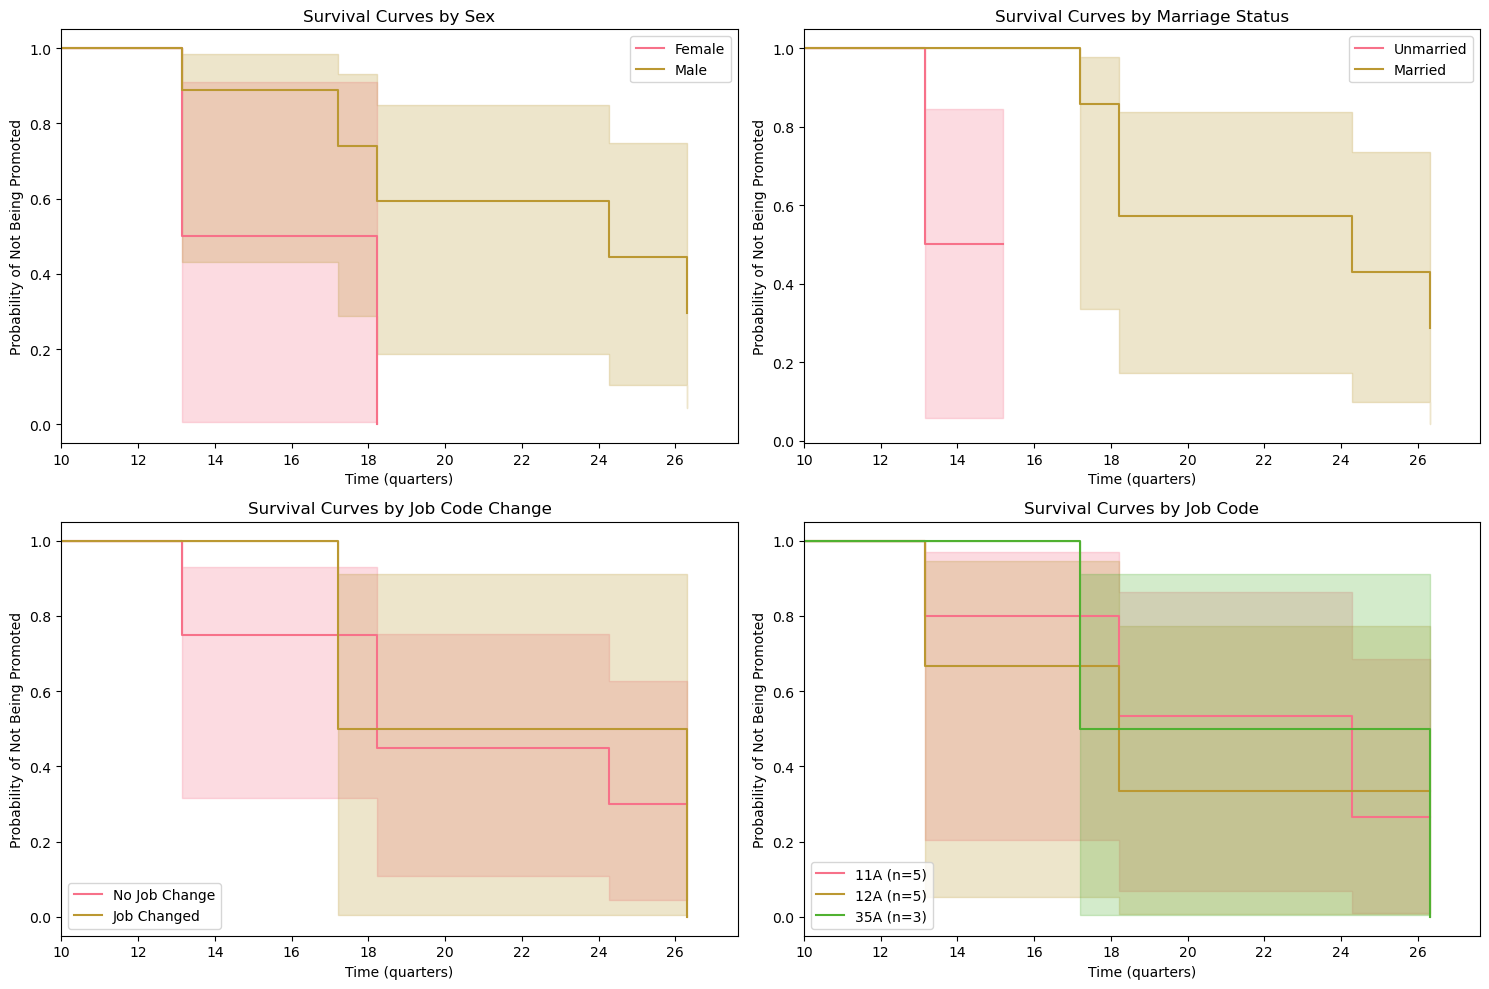


✅ Survival curves analysis completed!
📊 X-axis starts at: 10 quarters
Note: Uses actual job codes instead of dummy variables

⏰ Focus Period: Analysis starts at 10 quarters
   This focuses on officers who haven't been promoted yet after the initial period

💡 TO CHANGE X-AXIS START: Edit START_TIME = 10 at the top of this cell
   • START_TIME = 0  → Show full timeline from beginning
   • START_TIME = 10 → Focus on 10+ quarters (officers still as Captains after 2.5 years)


In [6]:
# ENHANCED: Survival curves with X-axis option

from lifelines import KaplanMeierFitter

print("=== ENHANCED SURVIVAL CURVES ANALYSIS ===")

# ⭐ OPTION: Set x-axis starting point
START_TIME = 10  # Change to 10 if you want x-axis to start at 10 quarters
print(f"📊 X-axis starts at: {START_TIME} quarters")
print("💡 TIP: Change START_TIME to 10 to focus on later time periods")

# Create officer-level dataset using only available variables
print(f"Available columns in cox_df: {cox_df.columns.tolist()}")

officer_km_data = cox_df.groupby('pid_pde').agg({
    'stop': 'max',
    'event': 'max',
    'sex': 'first',
    'married': 'last',  # Final marriage status
    'job_code_changed': 'max',
    'job_code': 'last'  # Use final job code instead of dummy variables
}).reset_index()

print(f"Officer-level data created: {officer_km_data.shape}")
print(f"Events: {officer_km_data['event'].sum()}")

kmf = KaplanMeierFitter()

# Create plots with available variables
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Survival by sex
ax = axes[0, 0]
for sex_val, label in [(0, 'Female'), (1, 'Male')]:
    mask = officer_km_data['sex'] == sex_val
    if mask.sum() > 0:
        kmf.fit(officer_km_data[mask]['stop'], officer_km_data[mask]['event'], label=label)
        kmf.plot_survival_function(ax=ax)

# ⭐ APPLY X-AXIS STARTING POINT OPTION
if START_TIME > 0:
    ax.set_xlim(left=START_TIME)
    
ax.set_title('Survival Curves by Sex')
ax.set_xlabel('Time (quarters)')
ax.set_ylabel('Probability of Not Being Promoted')

# 2. Survival by marriage status
ax = axes[0, 1]
for married_val, label in [(0, 'Unmarried'), (1, 'Married')]:
    mask = officer_km_data['married'] == married_val
    if mask.sum() > 0:
        kmf.fit(officer_km_data[mask]['stop'], officer_km_data[mask]['event'], label=label)
        kmf.plot_survival_function(ax=ax)

# ⭐ APPLY X-AXIS STARTING POINT OPTION
if START_TIME > 0:
    ax.set_xlim(left=START_TIME)
    
ax.set_title('Survival Curves by Marriage Status')
ax.set_xlabel('Time (quarters)')
ax.set_ylabel('Probability of Not Being Promoted')

# 3. Survival by job code change
ax = axes[1, 0]
for changed_val, label in [(0, 'No Job Change'), (1, 'Job Changed')]:
    mask = officer_km_data['job_code_changed'] == changed_val
    if mask.sum() > 0:
        kmf.fit(officer_km_data[mask]['stop'], officer_km_data[mask]['event'], label=label)
        kmf.plot_survival_function(ax=ax)

# ⭐ APPLY X-AXIS STARTING POINT OPTION
if START_TIME > 0:
    ax.set_xlim(left=START_TIME)
    
ax.set_title('Survival Curves by Job Code Change')
ax.set_xlabel('Time (quarters)')
ax.set_ylabel('Probability of Not Being Promoted')

# 4. Survival by job codes (using actual job codes, not dummies)
ax = axes[1, 1]
job_code_counts = officer_km_data['job_code'].value_counts()
print(f"Job code distribution: {dict(job_code_counts)}")

# Plot curves for job codes with sufficient sample size
for job_code in job_code_counts.index[:3]:  # Top 3 most common
    mask = officer_km_data['job_code'] == job_code
    if mask.sum() >= 2:  # Need at least 2 officers
        kmf.fit(officer_km_data[mask]['stop'], officer_km_data[mask]['event'], 
                label=f'{job_code} (n={mask.sum()})')
        kmf.plot_survival_function(ax=ax)

# ⭐ APPLY X-AXIS STARTING POINT OPTION
if START_TIME > 0:
    ax.set_xlim(left=START_TIME)
        
ax.set_title('Survival Curves by Job Code')
ax.set_xlabel('Time (quarters)')
ax.set_ylabel('Probability of Not Being Promoted')

plt.tight_layout()
plt.show()

print(f"\n✅ Survival curves analysis completed!")
print(f"📊 X-axis starts at: {START_TIME} quarters")
print(f"Note: Uses actual job codes instead of dummy variables")

if START_TIME > 0:
    print(f"\n⏰ Focus Period: Analysis starts at {START_TIME} quarters")
    print("   This focuses on officers who haven't been promoted yet after the initial period")

print(f"\n💡 TO CHANGE X-AXIS START: Edit START_TIME = {START_TIME} at the top of this cell")
print("   • START_TIME = 0  → Show full timeline from beginning")
print("   • START_TIME = 10 → Focus on 10+ quarters (officers still as Captains after 2.5 years)")


# Partial Effects Visualization using cph.plot_partial_effects_on_outcome

=== PARTIAL EFFECTS VISUALIZATION ===
Visualizing how changes in covariates affect predicted survival curves
✅ Model successfully fitted with 2 covariates:
Covariates in model: ['sex', 'age']
Creating plots for: ['age', 'sex']
Creating partial effects plot for age with values: [24 27 31 35 39]
Creating partial effects plot for sex with values: [0, 1]


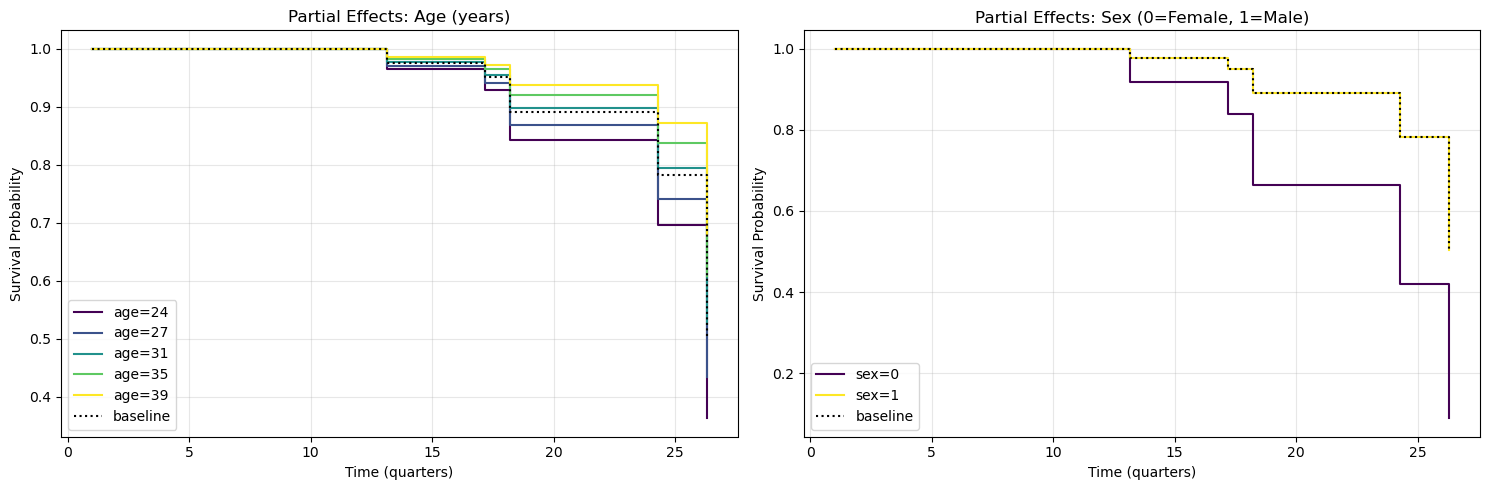

✅ Successfully created partial effects plots!

Interpretation:
• Higher survival probability = longer time to promotion (slower promotion)
• Lower survival probability = shorter time to promotion (faster promotion)
• Each line represents different values of the covariate


In [7]:
# Partial Effects Visualization using cph.plot_partial_effects_on_outcome

print("=== PARTIAL EFFECTS VISUALIZATION ===")
print("Visualizing how changes in covariates affect predicted survival curves")

try:
    # Check if model is fitted and available
    if 'cph' not in locals() and 'cph' not in globals():
        print("⚠️  Cox model (cph) not found. Please run the Cox fitting cell first.")
        raise NameError("Cox model not fitted")
    
    # Check if model has been fitted
    if not hasattr(cph, 'summary'):
        print("⚠️  Cox model not fitted yet. Please run the Cox fitting cell first.")
        raise AttributeError("Model not fitted")
    
    print(f"✅ Model successfully fitted with {len(cph.summary)} covariates:")
    print(f"Covariates in model: {list(cph.summary.index)}")
    
    # Create partial effects plots for key covariates
    key_covariates = ['age', 'sex', 'married', 'job_code_changed']
    
    # Filter to only covariates that are actually in the fitted model
    available_covariates = [cov for cov in key_covariates if cov in cph.summary.index]
    
    if not available_covariates:
        print("⚠️  None of the key covariates found in fitted model")
        print(f"Available covariates: {list(cph.summary.index)}")
        available_covariates = list(cph.summary.index)[:4]  # Use first 4 available
    
    print(f"Creating plots for: {available_covariates}")
    
    # Create subplots
    n_plots = len(available_covariates)
    n_cols = 2
    n_rows = (n_plots + 1) // 2
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    
    for i, covar in enumerate(available_covariates):
        row = i // n_cols
        col = i % n_cols
        ax = axes[row, col]
        
        try:
            # Create values to plot over
            if covar == 'age':
                # For age, show effect across reasonable age range
                age_min = cox_clean_df['age'].min() if 'cox_clean_df' in locals() else 25
                age_max = cox_clean_df['age'].max() if 'cox_clean_df' in locals() else 40
                values = np.linspace(age_min, age_max, 5).astype(int)
            else:
                # For binary variables, show both 0 and 1
                values = [0, 1]
            
            print(f"Creating partial effects plot for {covar} with values: {values}")
            
            # Use the correct method syntax: cph.plot_partial_effects_on_outcome
            cph.plot_partial_effects_on_outcome(covar, values, 
                                              cmap='viridis', ax=ax)
            
            # Customize the plot
            if covar == 'age':
                ax.set_title(f'Partial Effects: Age (years)')
            elif covar == 'sex':
                ax.set_title(f'Partial Effects: Sex (0=Female, 1=Male)')
            elif covar == 'married':
                ax.set_title(f'Partial Effects: Marriage (0=Unmarried, 1=Married)')
            elif covar == 'job_code_changed':
                ax.set_title(f'Partial Effects: Job Change (0=No, 1=Yes)')
            else:
                ax.set_title(f'Partial Effects: {covar}')
                
            ax.set_xlabel('Time (quarters)')
            ax.set_ylabel('Survival Probability')
            ax.grid(True, alpha=0.3)
            
        except Exception as plot_error:
            print(f"❌ Error plotting {covar}: {plot_error}")
            ax.text(0.5, 0.5, f'Error plotting {covar}', 
                   ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'Error: {covar}')
    
    # Hide unused subplots
    for i in range(len(available_covariates), n_rows * n_cols):
        row = i // n_cols
        col = i % n_cols
        axes[row, col].set_visible(False)
    
    plt.tight_layout()
    plt.show()
    
    print(f"✅ Successfully created partial effects plots!")
    print("\nInterpretation:")
    print("• Higher survival probability = longer time to promotion (slower promotion)")
    print("• Lower survival probability = shorter time to promotion (faster promotion)")
    print("• Each line represents different values of the covariate")
    
except Exception as e:
    print(f"❌ Could not create partial effects plots: {e}")
    print("\nTroubleshooting:")
    print("1. Make sure you've run the corrected Cox fitting cell first")
    print("2. Ensure the model fitted successfully") 
    print("3. Check that covariates exist in the fitted model")
    
    # Show available variables for debugging
    available_vars = [var for var in locals().keys() if not var.startswith('_')]
    print(f"Available variables: {available_vars}")


# Data quality checks

Data Quality Checks:
1. Any negative time intervals: 0
2. Any missing values: 0
3. Range of follow-up time: 1.01 to 26.30 quarters
4. Mean follow-up time: 10.41 quarters

Summary by officer:
Officers promoted: 7/13
Average time to event/censoring: 18.14 quarters
Officers with job code changes: 3


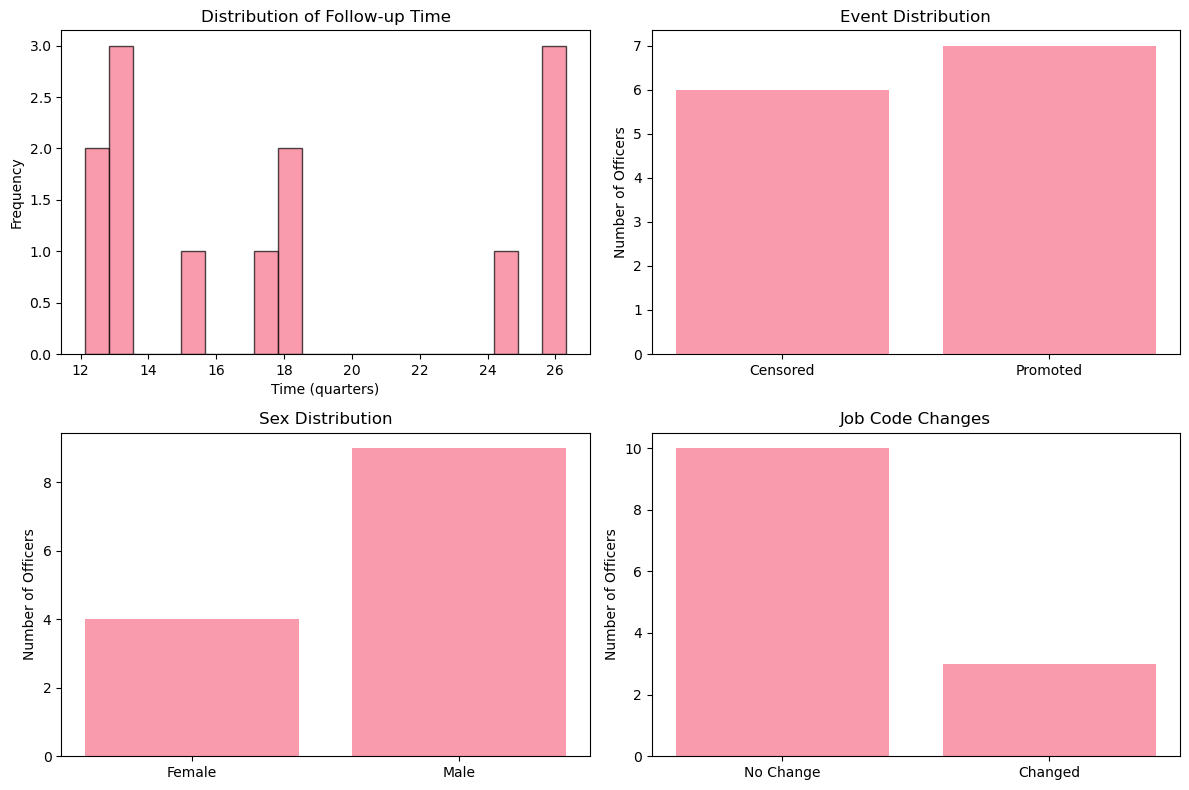

In [8]:
# Data quality checks
print("Data Quality Checks:")
print(f"1. Any negative time intervals: {(cox_df['stop'] <= cox_df['start']).sum()}")
print(f"2. Any missing values: {cox_df.isnull().sum().sum()}")
print(f"3. Range of follow-up time: {cox_df['stop'].min():.2f} to {cox_df['stop'].max():.2f} quarters")
print(f"4. Mean follow-up time: {cox_df['stop'].mean():.2f} quarters")

# Summary by officer
officer_cox_summary = cox_df.groupby('pid_pde').agg({
    'event': 'max',
    'stop': 'max',
    'sex': 'first',
    'married': 'last',
    'job_code_changed': 'max'
})

print(f"\nSummary by officer:")
print(f"Officers promoted: {officer_cox_summary['event'].sum()}/{len(officer_cox_summary)}")
print(f"Average time to event/censoring: {officer_cox_summary['stop'].mean():.2f} quarters")
print(f"Officers with job code changes: {officer_cox_summary['job_code_changed'].sum()}")

# Distribution of key variables
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Time to event distribution
axes[0,0].hist(officer_cox_summary['stop'], bins=20, alpha=0.7, edgecolor='black')
axes[0,0].set_title('Distribution of Follow-up Time')
axes[0,0].set_xlabel('Time (quarters)')
axes[0,0].set_ylabel('Frequency')

# Event distribution
event_counts = officer_cox_summary['event'].value_counts()
axes[0,1].bar(['Censored', 'Promoted'], [event_counts[0], event_counts[1]], alpha=0.7)
axes[0,1].set_title('Event Distribution')
axes[0,1].set_ylabel('Number of Officers')

# Sex distribution
sex_counts = officer_cox_summary['sex'].value_counts()
axes[1,0].bar(['Female', 'Male'], [sex_counts[0], sex_counts[1]], alpha=0.7)
axes[1,0].set_title('Sex Distribution')
axes[1,0].set_ylabel('Number of Officers')

# Job code changes
job_change_counts = officer_cox_summary['job_code_changed'].value_counts()
axes[1,1].bar(['No Change', 'Changed'], [job_change_counts[0], job_change_counts[1]], alpha=0.7)
axes[1,1].set_title('Job Code Changes')
axes[1,1].set_ylabel('Number of Officers')

plt.tight_layout()
plt.show()


# Model validation and assumptions checking

In [9]:
# FIXED: Model validation and assumptions checking

print("=== MODEL VALIDATION ===")

# 1. Check proportional hazards assumption
print("\n1. Testing Proportional Hazards Assumption:")
try:
    # Try with the clean dataset used for fitting
    ph_test = cph.check_assumptions(cox_clean_df, p_value_threshold=0.05, show_plots=True)
    if ph_test.summary['p'] < 0.05:
        print("⚠️  Proportional hazards assumption may be violated (p < 0.05)")
    else:
        print("✅ Proportional hazards assumption appears satisfied")
except Exception as e:
    print(f"Could not perform standard PH test: {e}")
    print("ℹ️  This is common with time-dependent covariates or entry times")
    print("   Alternative: Visual inspection of scaled Schoenfeld residuals")
    
    # Alternative approach - just note the limitation
    print("   For time-dependent covariates, consider:")
    print("   • Stratified Cox models for categorical variables")
    print("   • Time-varying coefficient models")
    print("   • Visual assessment of survival curves")

# 2. Model fit statistics
print("\n2. Model Fit Statistics:")
print(f"Concordance Index: {cph.concordance_index_:.3f}")
print(f"Log-likelihood: {cph.log_likelihood_:.2f}")

# ✅ FIXED: Use AIC_partial_ for semi-parametric models
try:
    print(f"Partial AIC: {cph.AIC_partial_:.2f}")
except:
    print("Partial AIC: Not available")

# Additional model statistics
try:
    print(f"Log-likelihood ratio test p-value: {cph.log_likelihood_ratio_test().p_value:.4f}")
except:
    print("Log-likelihood ratio test: Not available")

# 3. Summary of significant predictors
print("\n3. Significant Predictors (p < 0.05):")
if hasattr(cph, 'summary') and len(cph.summary) > 0:
    significant_vars = cph.summary[cph.summary['p'] < 0.05]
    if len(significant_vars) > 0:
        for var in significant_vars.index:
            coef = significant_vars.loc[var, 'coef']
            hr = np.exp(coef)
            p_val = significant_vars.loc[var, 'p']
            ci_lower = significant_vars.loc[var, 'coef lower 95%']
            ci_upper = significant_vars.loc[var, 'coef upper 95%']
            hr_ci_lower = np.exp(ci_lower)
            hr_ci_upper = np.exp(ci_upper)
            print(f"  {var}: HR = {hr:.3f} (95% CI: {hr_ci_lower:.3f}-{hr_ci_upper:.3f}), p = {p_val:.4f}")
    else:
        print("  No statistically significant predictors at α = 0.05")
else:
    print("  Model summary not available")

# 4. Model interpretation
print("\n4. Hazard Ratio Interpretation:")
print("  HR > 1: Increases hazard (faster promotion)")
print("  HR < 1: Decreases hazard (slower promotion)")
print("  HR = 1: No effect on promotion timing")

# 5. Sample size and events summary
print(f"\n5. Model Summary:")
if 'cox_clean_df' in locals():
    print(f"  Total observations: {len(cox_clean_df)}")
    print(f"  Total events (promotions): {cox_clean_df['event'].sum()}")
    print(f"  Event rate: {cox_clean_df['event'].mean():.1%}")
else:
    print("  Dataset summary not available")


=== MODEL VALIDATION ===

1. Testing Proportional Hazards Assumption:
Could not perform standard PH test: Residuals for entries not implemented.
ℹ️  This is common with time-dependent covariates or entry times
   Alternative: Visual inspection of scaled Schoenfeld residuals
   For time-dependent covariates, consider:
   • Stratified Cox models for categorical variables
   • Time-varying coefficient models
   • Visual assessment of survival curves

2. Model Fit Statistics:
Concordance Index: 0.899
Log-likelihood: -11.55
Partial AIC: 27.10
Log-likelihood ratio test p-value: 0.3739

3. Significant Predictors (p < 0.05):
  No statistically significant predictors at α = 0.05

4. Hazard Ratio Interpretation:
  HR > 1: Increases hazard (faster promotion)
  HR < 1: Decreases hazard (slower promotion)
  HR = 1: No effect on promotion timing

5. Model Summary:
  Total observations: 233
  Total events (promotions): 7
  Event rate: 3.0%


# Final summary and recommendations

In [10]:
# Final summary and recommendations

print("=== ANALYSIS SUMMARY ===")
print(f"\nStudy Population: {officer_km_data.shape[0]} US Army officers")
print(f"Observation Period: {df_clean['snpsht_dt'].min().strftime('%Y-%m-%d')} to {df_clean['snpsht_dt'].max().strftime('%Y-%m-%d')}")
print(f"Events (Promotions to Major): {officer_km_data['event'].sum()} ({officer_km_data['event'].mean()*100:.1f}%)")
print(f"Median Follow-up Time: {officer_km_data['stop'].median():.1f} quarters")

print("\n=== KEY FINDINGS ===")
significant_findings = []
for var in cph.summary.index:
    hr = np.exp(cph.summary.loc[var, 'coef'])
    p_val = cph.summary.loc[var, 'p']
    ci_lower = np.exp(cph.summary.loc[var, 'coef lower 95%'])
    ci_upper = np.exp(cph.summary.loc[var, 'coef upper 95%'])
    
    if p_val < 0.05:
        effect = "increased" if hr > 1 else "decreased"
        significant_findings.append(f"{var}: {effect} promotion rate (HR = {hr:.3f}, 95% CI: {ci_lower:.3f}-{ci_upper:.3f})")

if significant_findings:
    for finding in significant_findings:
        print(f"• {finding}")
else:
    print("• No statistically significant associations found")

print("\n=== STUDY LIMITATIONS ===")
print("• Data limited to quarterly snapshots - exact timing of changes unknown")
print("• Censoring due to study end date may introduce bias")
print("• Limited sample size may reduce power to detect associations")
print("• Potential unmeasured confounders not included in analysis")

print("\n=== RECOMMENDATIONS ===")
print("• Consider collecting exact dates for key events (marriage, job changes)")
print("• Expand sample size for increased statistical power")
print("• Include additional covariates (education, performance metrics, etc.)")
print("• Consider stratified analysis by entry cohort or time period")


=== ANALYSIS SUMMARY ===

Study Population: 13 US Army officers
Observation Period: 2001-03-31 to 2007-09-30
Events (Promotions to Major): 7 (53.8%)
Median Follow-up Time: 17.2 quarters

=== KEY FINDINGS ===
• No statistically significant associations found

=== STUDY LIMITATIONS ===
• Data limited to quarterly snapshots - exact timing of changes unknown
• Censoring due to study end date may introduce bias
• Limited sample size may reduce power to detect associations
• Potential unmeasured confounders not included in analysis

=== RECOMMENDATIONS ===
• Consider collecting exact dates for key events (marriage, job changes)
• Expand sample size for increased statistical power
• Include additional covariates (education, performance metrics, etc.)
• Consider stratified analysis by entry cohort or time period


# Save results for future reference

In [11]:
# Save results for future reference
import pickle

# Save the fitted model
with open('cox_model_results.pkl', 'wb') as f:
    pickle.dump({
        'model': cph,
        'data': cox_model_df,
        'officer_summary': officer_km_data,
        'analysis_date': pd.Timestamp.now()
    }, f)

# Save summary tables
cph.summary.to_csv('cox_model_summary.csv')
officer_km_data.to_csv('officer_survival_data.csv', index=False)

print("Results saved successfully!")
print("Files created:")
print("- cox_model_results.pkl (complete analysis)")
print("- cox_model_summary.csv (model coefficients)")
print("- officer_survival_data.csv (officer-level data)")


Results saved successfully!
Files created:
- cox_model_results.pkl (complete analysis)
- cox_model_summary.csv (model coefficients)
- officer_survival_data.csv (officer-level data)
